In [28]:
%pip install pandas matplotlib load_datasets

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement load_datasets (from versions: none)
ERROR: No matching distribution found for load_datasets


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

ModuleNotFoundError: No module named 'load_datasets'

In [3]:
top_10 = df.sort_values(by = "total_litres_of_pure_alcohol", ascending = False).head(10)
print("Primi 10 paesi per consumo di alcol")
print(top_10[["country", "total_litres_of_pure_alcohol"]])


Primi 10 paesi per consumo di alcol
                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
61               France                          11.8
45       Czech Republic                          11.8
141  Russian Federation                          11.5
99           Luxembourg                          11.4
155            Slovakia                          11.4
81              Ireland                          11.4


In [4]:
birra_media = df["beer_servings"].mean()
vino_media = df["wine_servings"].mean()
spirit_media = df["spirit_servings"].mean()
print(f"Consumo medio di birra: {birra_media:.2f}, vino: {vino_media:.2f}, alcolici: {spirit_media:.2f}")

Consumo medio di birra: 106.16, vino: 49.45, alcolici: 80.99


In [7]:
df['alcohol_index'] = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean(axis=1)
max_index_country = df.loc[df["alcohol_index"].idxmax()]
print(f"Il paese con l'indice di consumo di alcol più alto è {max_index_country['country']} con un indice di {max_index_country['alcohol_index']:.2f}")

Il paese con l'indice di consumo di alcol più alto è Andorra con un indice di 231.67


In [9]:
beer_over100 = df[df["beer_servings"]>100]
print("Paesi con consumo di birra superiore a 100 porzioni:")
print(beer_over100[["country", "beer_servings"]])

Paesi con consumo di birra superiore a 100 porzioni:
               country  beer_servings
3              Andorra            245
4               Angola            217
5    Antigua & Barbuda            102
6            Argentina            193
8            Australia            261
..                 ...            ...
182     United Kingdom            219
184                USA            249
185            Uruguay            115
188          Venezuela            333
189            Vietnam            111

[79 rows x 2 columns]


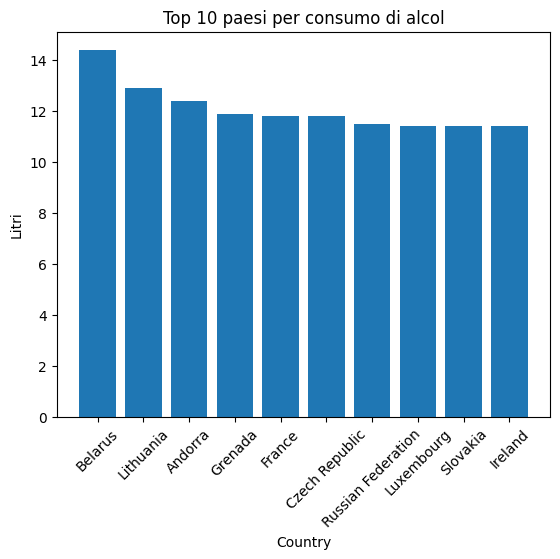

In [17]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.bar(top_10["country"], top_10["total_litres_of_pure_alcohol"])
plt.title("Top 10 paesi per consumo di alcol")
plt.xlabel("Country")
plt.ylabel("Litri")
plt.xticks(rotation=45)
plt.show()

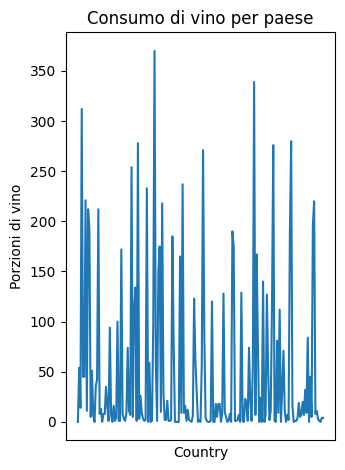

In [27]:
plt.subplot(1,2,1)
df_wine_sortedn = df.sort_values(by="country")
plt.plot(df_wine_sortedn["country"], df_wine_sortedn["wine_servings"])
plt.title("Consumo di vino per paese")
plt.xlabel("Country")
plt.ylabel("Porzioni di vino")
plt.xticks([]) #etichette nascoste per evitare sovrapposizioni
plt.tight_layout()


In [43]:
#ES2
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [53]:
country_analisi = df.groupby("job_location")["salary_year_avg"].agg(job_count="count", salary_mean="mean", salary_min="min", salary_max="max").reset_index()
country_analisi = country_analisi.fillna(0)
print("Analisi per paese")
print(country_analisi.sort_values("job_count", ascending=False))

Analisi per paese
                     job_location  job_count    salary_mean  salary_min  \
607                      Anywhere       3279  131601.899679     16500.0   
10652                New York, NY       1044  137112.031040     42500.0   
15611               United States        531  143879.125971     33488.5   
13307           San Francisco, CA        501  161541.553097     41500.0   
842                   Atlanta, GA        442  121636.475255     35000.0   
...                           ...        ...            ...         ...   
2      's-Heerenberg, Netherlands          0       0.000000         0.0   
17216    จ.กรุงเทพมหานคร Thailand          0       0.000000         0.0   
0       's-Graveland, Netherlands          0       0.000000         0.0   
17199           Łozienica, Poland          0       0.000000         0.0   
17198     İzmit, Kocaeli, Türkiye          0       0.000000         0.0   

       salary_max  
607      650000.0  
10652    585000.0  
15611    375000.0  
1

In [56]:
totale_offerte = country_analisi["job_count"].sum()
print(f"Totale offerte di lavoro: {totale_offerte}")

Totale offerte di lavoro: 21723


In [57]:
salary_min = country_analisi["salary_min"].min()
salary_max = country_analisi["salary_max"].max()
print(f"Salario minimo: {salary_min}, Salario massimo: {salary_max}")

Salario minimo: 0.0, Salario massimo: 960000.0


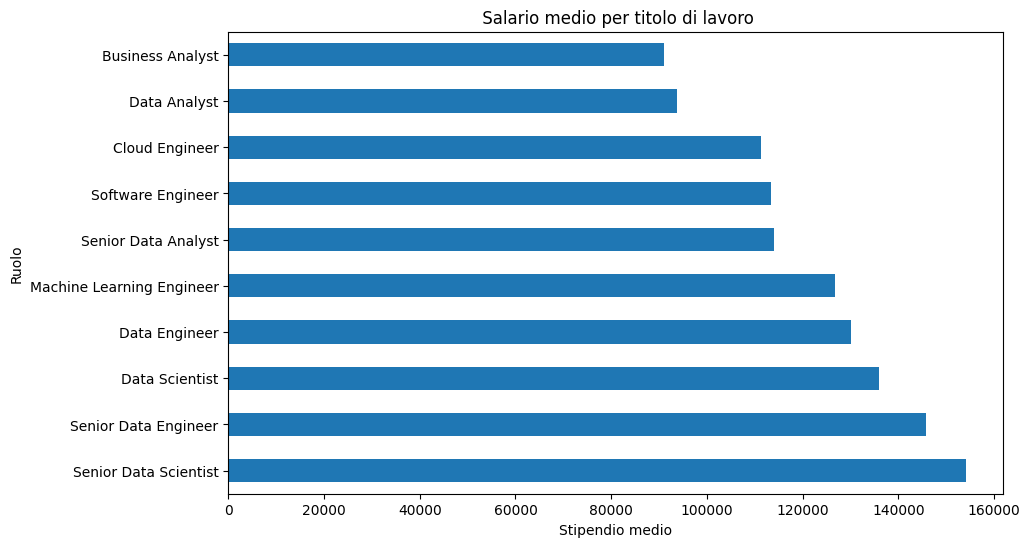

In [60]:
job_salary = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=False).dropna()
plt.figure(figsize=(10,6))
job_salary.plot(kind="barh")
plt.title(" Salario medio per titolo di lavoro")
plt.xlabel("Stipendio medio")
plt.ylabel("Ruolo")
plt.show()

In [62]:
#Es3
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [66]:
conto_medio_giorno = df.groupby("day")["total_bill"].agg(conto_medio = "mean", totale_conti = "count", minimo_conto = "min", massimo_conto = "max").reset_index()
print("Conto medio per giorno:")
print(conto_medio_giorno)

Conto medio per giorno:
    day  conto_medio  totale_conti  minimo_conto  massimo_conto
0   Fri    17.151579            19          5.75          40.17
1   Sat    20.441379            87          3.07          50.81
2   Sun    21.410000            76          7.25          48.17
3  Thur    17.682742            62          7.51          43.11


In [67]:
df["conto_persona"] = df["total_bill"] / df["size"]

In [68]:
giorno_conto_alto = conto_medio_giorno.loc[conto_medio_giorno["conto_medio"].idxmax()]
print(f"Il giorno con il conto medio più alto è {giorno_conto_alto['day']} con un conto medio di {giorno_conto_alto['conto_medio']:.2f}")

Il giorno con il conto medio più alto è Sun con un conto medio di 21.41


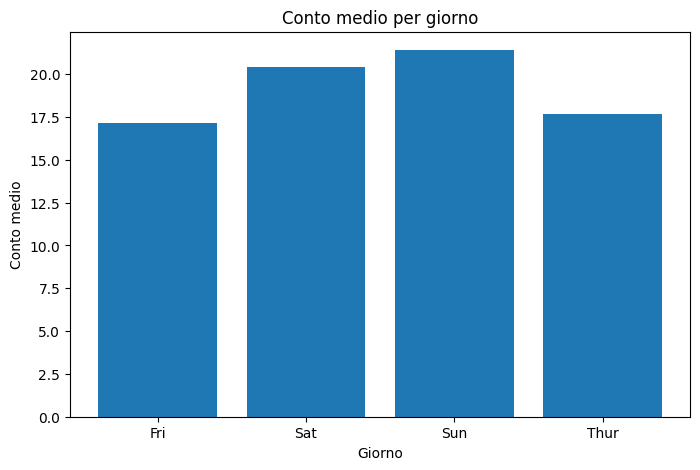

In [69]:
plt.figure(figsize=(8,5))
plt.bar(conto_medio_giorno["day"], conto_medio_giorno["conto_medio"])
plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.title("Conto medio per giorno")
plt.show()